# 13 · Edge Detection: Parameter Study

LRT4012 Robot Vision · Fall 2026


## Intensity changes and derivative operators

An edge is a localized image-intensity change. It may indicate an object boundary, texture, a shadow, or a reflection.

$$\nabla I=(I_x,I_y)^T,\quad m=\sqrt{I_x^2+I_y^2},\quad \theta=\operatorname{atan2}(I_y,I_x),\quad \nabla^2 I=I_{xx}+I_{yy}.$$

$I(x,y)$ is grayscale intensity at pixel coordinates $(x,y)$; $I_x,I_y$ are first spatial derivatives, $I_{xx},I_{yy}$ are second derivatives, $m$ is gradient magnitude, and $\theta$ is the direction of increasing intensity, normal to the edge. Image $y$ increases downward. Sobel approximates first derivatives; the Laplacian approximates the sum of second derivatives. Compute derivatives in floating point to retain negative responses.

Canny combines Gaussian smoothing, gradient estimation, non-maximum suppression along the gradient, and hysteresis. The lower threshold connects weak responses to strong responses above the upper threshold. A threshold on absolute Laplacian response is a comparison baseline, not a zero-crossing detector.


## Experimental protocol and files

Official images are read from `imagenes`. Personal notebooks belong in `student_work`; captured or generated images belong in `student_work/imagenes`. No cell writes to the official resource directory. Relative discovery supports a cloned course repository; `VISION_ROBOTICA_REPO` is an optional local override.

Predict the effect of each parameter before running a comparison. Keep image size and acquisition conditions fixed. Timing reports the median of 30 runs after one warm-up, excludes plotting and file access, and describes this computer only. Random generators use seed 4012. A missing detection is an experimental result, not evidence that no object exists.


In [1]:
from pathlib import Path
import os, time
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

def find_repository():
    candidates = []
    if os.environ.get('VISION_ROBOTICA_REPO'):
        candidates.append(Path(os.environ['VISION_ROBOTICA_REPO']).expanduser())
    candidates += [Path.cwd(), *Path.cwd().parents]
    for root in candidates:
        if (root / 'requirements.txt').is_file() and (root / 'imagenes').is_dir():
            return root.resolve()
    raise FileNotFoundError('Open Jupyter inside the course repository, or set VISION_ROBOTICA_REPO to its root.')

REPO = find_repository()
IMAGE_DIR = REPO / 'imagenes'  # Read-only official resources.
# Save your own notebook and generated images in student_work/ and student_work/imagenes/.
cv2.setRNGSeed(4012)
cv2.setNumThreads(1)
rng = np.random.default_rng(4012)
plt.rcParams.update({'figure.dpi':100, 'font.size':10})

def load_image(name, max_side=640):
    image = cv2.imread(str(IMAGE_DIR / name), cv2.IMREAD_COLOR)
    if image is None:
        raise FileNotFoundError(f'Official resource could not be read: {name}')
    h, w = image.shape[:2]
    if max(h, w) > max_side:
        scale = max_side / max(h, w)
        image = cv2.resize(image, (round(w*scale), round(h*scale)), interpolation=cv2.INTER_AREA)
    return image

def gray(image): return cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

def panels(images, titles):
    fig, axes = plt.subplots(1, len(images), figsize=(4*len(images), 3.5), squeeze=False)
    for ax, im, title in zip(axes[0], images, titles):
        if im.ndim == 3:
            ax.imshow(cv2.cvtColor(im, cv2.COLOR_BGR2RGB))
        else:
            ax.imshow(im, cmap='gray', vmin=0, vmax=255)
        ax.set_title(title)
        ax.axis('off')
    fig.tight_layout()
    plt.show()

def timed_ms(fn, repetitions=30):
    fn()  # Warm-up.
    times = []
    for _ in range(repetitions):
        start = time.perf_counter()
        fn()
        times.append((time.perf_counter()-start)*1000)
    return float(np.median(times))

def mask_metrics(prediction, reference):
    a, b = prediction.astype(bool), reference.astype(bool)
    tp = int(np.count_nonzero(a & b))
    fp = int(np.count_nonzero(a & ~b))
    fn = int(np.count_nonzero(~a & b))
    return {'IoU': tp/(tp+fp+fn) if tp+fp+fn else 1.0,
            'precision': tp/(tp+fp) if tp+fp else np.nan,
            'recall': tp/(tp+fn) if tp+fn else np.nan,
            'F1': 2*tp/(2*tp+fp+fn) if 2*tp+fp+fn else 1.0}


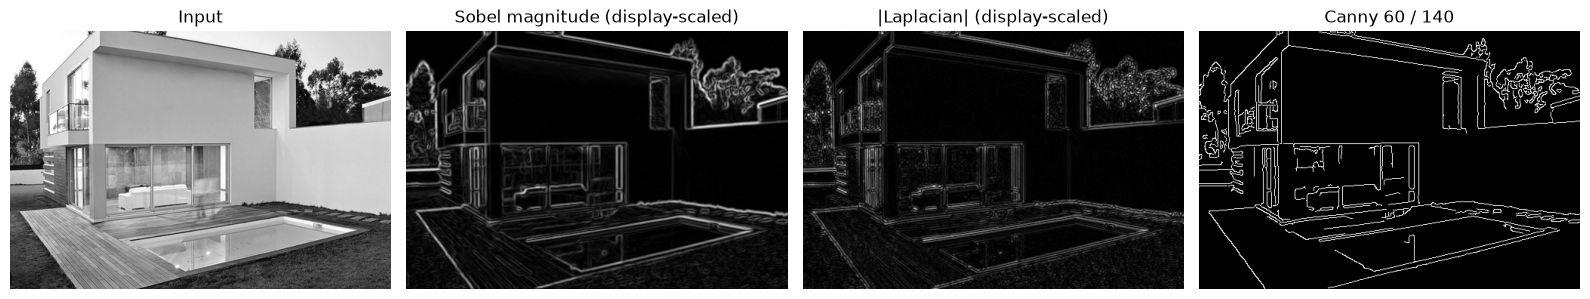

Input shape: (342, 505) | derivative type: float32 | negative gx pixels: 73539


In [2]:
image = load_image('casa.png')
g = gray(image)
smooth = cv2.GaussianBlur(g, (5, 5), 1.2)
gx = cv2.Sobel(smooth, cv2.CV_32F, 1, 0, ksize=3)
gy = cv2.Sobel(smooth, cv2.CV_32F, 0, 1, ksize=3)
magnitude = cv2.magnitude(gx, gy)
laplacian = cv2.Laplacian(smooth, cv2.CV_32F, ksize=3)
canny = cv2.Canny(smooth, 60, 140, L2gradient=True)
def display_response(a):
    return np.uint8(np.clip(np.abs(a) / max(float(np.max(np.abs(a))), 1e-6) * 255, 0, 255))
panels([g, display_response(magnitude), display_response(laplacian), canny],
       ['Input', 'Sobel magnitude (display-scaled)', '|Laplacian| (display-scaled)', 'Canny 60 / 140'])
print('Input shape:', g.shape, '| derivative type:', gx.dtype, '| negative gx pixels:', int((gx<0).sum()))


## Thresholds and density

Edge density is $d=N_e/(HW)$, where $N_e$ counts selected edge pixels and $H,W$ are image height and width. A high density may mean detail or noise; it is not accuracy. Sobel and Laplacian thresholds have different response units and cannot be compared by choosing the same numeric value.


,low,high,density,median_ms
0,30,70,0.096265,0.54055
1,60,140,0.055544,0.35420
2,100,220,0.038475,0.27910


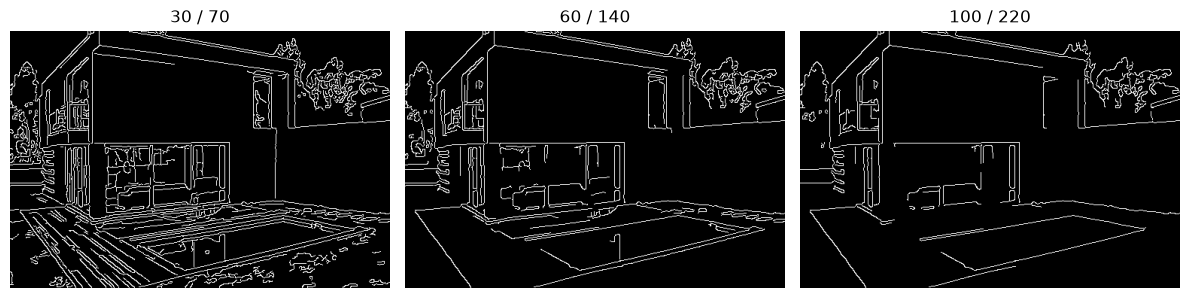

In [3]:
rows = []
maps = []
for low, high in [(30, 70), (60, 140), (100, 220)]:
    fn = lambda: cv2.Canny(smooth, low, high, L2gradient=True)
    edge = fn()
    maps.append(edge)
    rows.append({'low':low, 'high':high, 'density':np.mean(edge>0), 'median_ms':timed_ms(fn)})
display(pd.DataFrame(rows))
panels(maps, ['30 / 70', '60 / 140', '100 / 220'])


## Optional threshold control

The static comparison above remains the reproducible baseline. The control studies the high-to-low threshold ratio.


In [ ]:
import ipywidgets as widgets
def inspect_threshold(low=60, ratio=2.3):
    high = int(round(low*ratio))
    edge = cv2.Canny(smooth, low, high, L2gradient=True)
    panels([g, edge], ['Input', f'Canny {low}/{high}; density={np.mean(edge>0):.3f}'])
widgets.interact(inspect_threshold, low=widgets.IntSlider(value=60,min=10,max=120,step=10,continuous_update=False),
                 ratio=widgets.FloatSlider(value=2.3,min=1.2,max=3.5,step=0.1,continuous_update=False))


interactive(children=(IntSlider(value=60, continuous_update=False, description='low', max=120, min=10, step=10…

<function __main__.inspect_threshold(low=60, ratio=2.3)>

## Robotic interpretation

Select thresholds that retain a task-relevant line. State which evidence the density table cannot provide. Explain why changes in exposure require checking the same thresholds again.


## References

- [OpenCV: image gradients](https://docs.opencv.org/4.x/d5/d0f/tutorial_py_gradients.html)
- [OpenCV: Canny](https://docs.opencv.org/4.x/da/d22/tutorial_py_canny.html)
